In [3]:
import numpy as np
import matplotlib.pyplot as plt
import harmonica as hm
import verde as vd
import numpy as np
import time

import magali as mg


In [4]:
SEED = 5
rng = np.random.default_rng(SEED)
region = [30, 70, 30, 70]

In [6]:

def simple_model(region, spacing, rng):
    sensor_sample_distance = 5

    dipole_coordinates = (50, 50, -5)
    dipole_moments = hm.magnetic_angles_to_vec(1e-13, 30, 40)

    data = mg.dipole_bz_grid(
        region, spacing, sensor_sample_distance, dipole_coordinates, dipole_moments
    )

    noise = 10
    data += rng.normal(0, noise, data.shape)

    return data, dipole_coordinates, dipole_moments


def one_interf_model(region, spacing, rng):
    sensor_sample_distance = 5

    dipole_coordinates = (
        np.concatenate([[50], [40]]),  # x
        np.concatenate([[50], [40]]),  # y
        np.concatenate([[-5], [-10]]),  # z
    )
    dipole_moments = hm.magnetic_angles_to_vec(
        inclination=np.concatenate([[30], [-30]]),
        declination=np.concatenate([[40], [40]]),
        intensity=np.concatenate([[10e-14], [10e-14]]),  # A·m²
    )

    data = mg.dipole_bz_grid(
        region, spacing, sensor_sample_distance, dipole_coordinates, dipole_moments
    )

    noise = 10
    data += rng.normal(0, noise, data.shape)

    return data, dipole_coordinates, dipole_moments

/home/yagomcastro/miniforge3/envs/magali-paper/lib/python3.12/site-packages/xrft/xrft.py:573: FutureWarning: Default ifft's behaviour (lag=None) changed! Default value of lag was zero (centered output coordinates) and is now set to transformed coordinate's attribute: 'direct_lag'.
  warnings.warn(msg, FutureWarning)
/home/yagomcastro/miniforge3/envs/magali-paper/lib/python3.12/site-packages/xrft/xrft.py:573: FutureWarning: Default ifft's behaviour (lag=None) changed! Default value of lag was zero (centered output coordinates) and is now set to transformed coordinate's attribute: 'direct_lag'.
  warnings.warn(msg, FutureWarning)


[49.99387179 49.99382618 -4.4035528 ]
-109.1385005419071
225


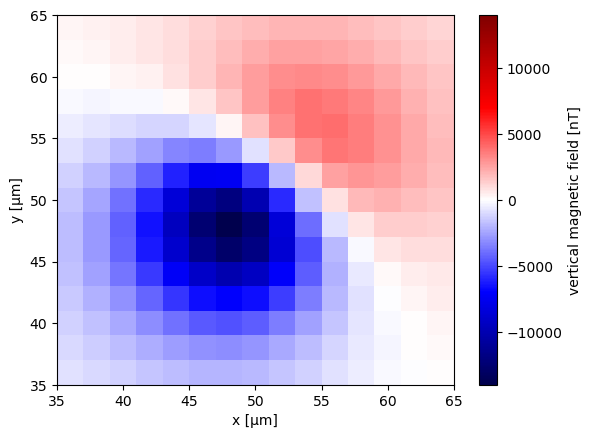

In [7]:
spacing = 2
data, dipole_coordinates, dipole_moments = simple_model(region, spacing, rng)
dx, dy, dz, tga = mg.gradient(data)

dataset = data.to_dataset()
dataset["dx"] = dx
dataset["dy"] = dy
dataset["dz"] = dz

dataset = dataset.sel(x=slice(35, 65), y=slice(35, 65))
dataset.bz.plot.pcolormesh(cmap="seismic")
table = vd.grid_to_table(dataset)

euler = hm.EulerDeconvolution(3)
euler.fit((table.x, table.y, table.z), (table.bz, table.dx, table.dy, table.dz))

print(euler.location_)
print(euler.base_level_)
print(table.bz.size)

/home/yagomcastro/miniforge3/envs/magali-paper/lib/python3.12/site-packages/xrft/xrft.py:573: FutureWarning: Default ifft's behaviour (lag=None) changed! Default value of lag was zero (centered output coordinates) and is now set to transformed coordinate's attribute: 'direct_lag'.
  warnings.warn(msg, FutureWarning)
/home/yagomcastro/miniforge3/envs/magali-paper/lib/python3.12/site-packages/xrft/xrft.py:573: FutureWarning: Default ifft's behaviour (lag=None) changed! Default value of lag was zero (centered output coordinates) and is now set to transformed coordinate's attribute: 'direct_lag'.
  warnings.warn(msg, FutureWarning)


[49.98249295 49.97656383 -4.69136554]
-101.33714702461084
961


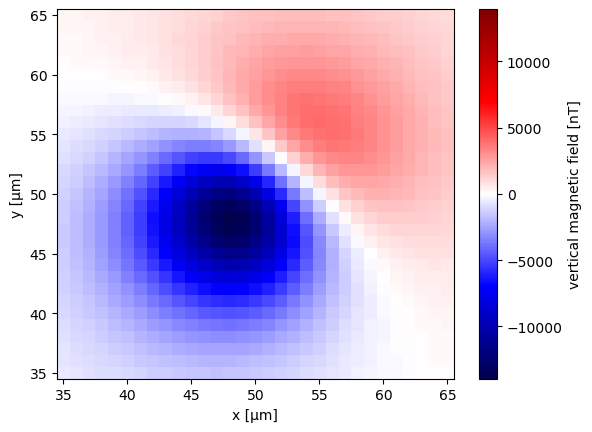

In [9]:
spacing = 1
data, dipole_coordinates, dipole_moments = simple_model(region, spacing, rng)
dx, dy, dz, tga = mg.gradient(data)

dataset = data.to_dataset()
dataset["dx"] = dx
dataset["dy"] = dy
dataset["dz"] = dz

dataset = dataset.sel(x=slice(35, 65), y=slice(35, 65))
dataset.bz.plot.pcolormesh(cmap="seismic")
table = vd.grid_to_table(dataset)

euler = hm.EulerDeconvolution(3)
euler.fit((table.x, table.y, table.z), (table.bz, table.dx, table.dy, table.dz))

print(euler.location_)
print(euler.base_level_)
print(table.bz.size)
plt.savefig("../assets/simple-model-1.png")

/home/yagomcastro/miniforge3/envs/magali-paper/lib/python3.12/site-packages/xrft/xrft.py:573: FutureWarning: Default ifft's behaviour (lag=None) changed! Default value of lag was zero (centered output coordinates) and is now set to transformed coordinate's attribute: 'direct_lag'.
  warnings.warn(msg, FutureWarning)
/home/yagomcastro/miniforge3/envs/magali-paper/lib/python3.12/site-packages/xrft/xrft.py:573: FutureWarning: Default ifft's behaviour (lag=None) changed! Default value of lag was zero (centered output coordinates) and is now set to transformed coordinate's attribute: 'direct_lag'.
  warnings.warn(msg, FutureWarning)


[49.99816406 49.99466485 -3.68059403]
-131.5162585611302
10000


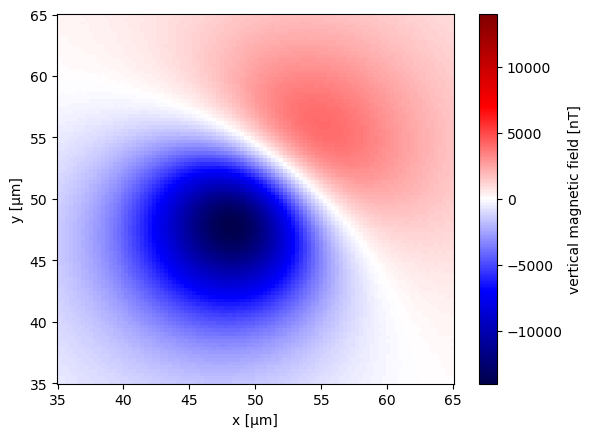

In [10]:
spacing = 0.3
data, dipole_coordinates, dipole_moments = simple_model(region, spacing, rng)
dx, dy, dz, tga = mg.gradient(data)

dataset = data.to_dataset()
dataset["dx"] = dx
dataset["dy"] = dy
dataset["dz"] = dz

dataset = dataset.sel(x=slice(35, 65), y=slice(35, 65))
dataset.bz.plot.pcolormesh(cmap="seismic")
table = vd.grid_to_table(dataset)

euler = hm.EulerDeconvolution(3)
euler.fit((table.x, table.y, table.z), (table.bz, table.dx, table.dy, table.dz))

print(euler.location_)
print(euler.base_level_)
print(table.bz.size)
plt.savefig("../assets/simple-model-2.png")

/home/yagomcastro/miniforge3/envs/magali-paper/lib/python3.12/site-packages/xrft/xrft.py:573: FutureWarning: Default ifft's behaviour (lag=None) changed! Default value of lag was zero (centered output coordinates) and is now set to transformed coordinate's attribute: 'direct_lag'.
  warnings.warn(msg, FutureWarning)
/home/yagomcastro/miniforge3/envs/magali-paper/lib/python3.12/site-packages/xrft/xrft.py:573: FutureWarning: Default ifft's behaviour (lag=None) changed! Default value of lag was zero (centered output coordinates) and is now set to transformed coordinate's attribute: 'direct_lag'.
  warnings.warn(msg, FutureWarning)


[49.48175415 50.04537229 -3.01001046]
378.1972763542837
225


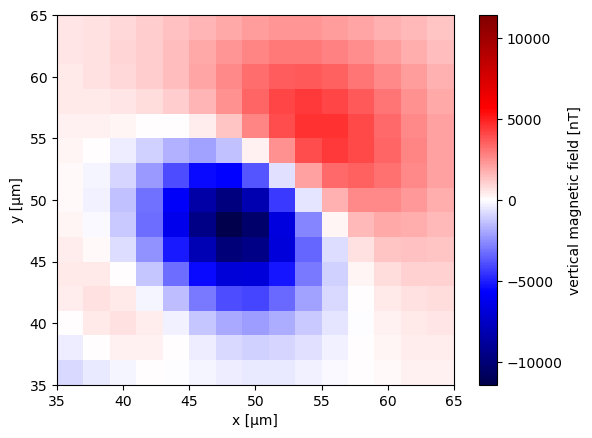

In [14]:
spacing = 2
data, dipole_coordinates, dipole_moments = one_interf_model(region, spacing, rng)
dx, dy, dz, tga = mg.gradient(data)

dataset = data.to_dataset()
dataset["dx"] = dx
dataset["dy"] = dy
dataset["dz"] = dz

dataset = dataset.sel(x=slice(35, 65), y=slice(35, 65))
dataset.bz.plot.pcolormesh(cmap="seismic")
table = vd.grid_to_table(dataset)

euler = hm.EulerDeconvolution(3)
euler.fit((table.x, table.y, table.z), (table.bz, table.dx, table.dy, table.dz))

print(euler.location_)
print(euler.base_level_)
print(table.bz.size)
plt.savefig("../assets/one-interf.png")

/home/yagomcastro/miniforge3/envs/magali-paper/lib/python3.12/site-packages/xrft/xrft.py:573: FutureWarning: Default ifft's behaviour (lag=None) changed! Default value of lag was zero (centered output coordinates) and is now set to transformed coordinate's attribute: 'direct_lag'.
  warnings.warn(msg, FutureWarning)
/home/yagomcastro/miniforge3/envs/magali-paper/lib/python3.12/site-packages/xrft/xrft.py:573: FutureWarning: Default ifft's behaviour (lag=None) changed! Default value of lag was zero (centered output coordinates) and is now set to transformed coordinate's attribute: 'direct_lag'.
  warnings.warn(msg, FutureWarning)


[49.46269597 49.99654953 -3.2735099 ]
345.9201483248214
961


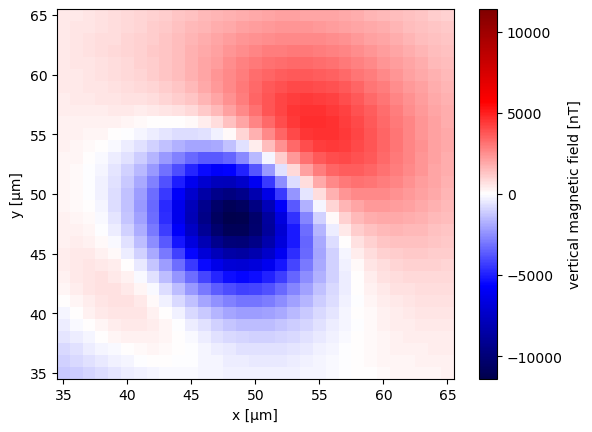

In [12]:
spacing = 1
data, dipole_coordinates, dipole_moments = one_interf_model(region, spacing, rng)
dx, dy, dz, tga = mg.gradient(data)

dataset = data.to_dataset()
dataset["dx"] = dx
dataset["dy"] = dy
dataset["dz"] = dz

dataset = dataset.sel(x=slice(35, 65), y=slice(35, 65))
dataset.bz.plot.pcolormesh(cmap="seismic")
table = vd.grid_to_table(dataset)

euler = hm.EulerDeconvolution(3)
euler.fit((table.x, table.y, table.z), (table.bz, table.dx, table.dy, table.dz))

print(euler.location_)
print(euler.base_level_)
print(table.bz.size)
plt.savefig("../assets/one-interf-1.png")

/home/yagomcastro/miniforge3/envs/magali-paper/lib/python3.12/site-packages/xrft/xrft.py:573: FutureWarning: Default ifft's behaviour (lag=None) changed! Default value of lag was zero (centered output coordinates) and is now set to transformed coordinate's attribute: 'direct_lag'.
  warnings.warn(msg, FutureWarning)
/home/yagomcastro/miniforge3/envs/magali-paper/lib/python3.12/site-packages/xrft/xrft.py:573: FutureWarning: Default ifft's behaviour (lag=None) changed! Default value of lag was zero (centered output coordinates) and is now set to transformed coordinate's attribute: 'direct_lag'.
  warnings.warn(msg, FutureWarning)


[49.47663618 49.99871654 -2.27358237]
390.3818924788481
10000


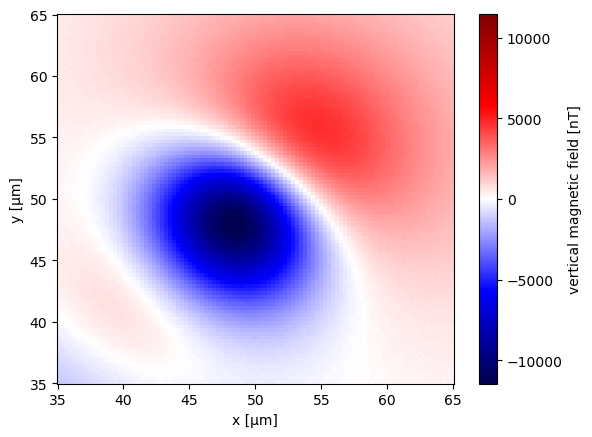

In [13]:
spacing = 0.3
data, dipole_coordinates, dipole_moments = one_interf_model(region, spacing, rng)
dx, dy, dz, tga = mg.gradient(data)

dataset = data.to_dataset()
dataset["dx"] = dx
dataset["dy"] = dy
dataset["dz"] = dz

dataset = dataset.sel(x=slice(35, 65), y=slice(35, 65))
dataset.bz.plot.pcolormesh(cmap="seismic")
table = vd.grid_to_table(dataset)

euler = hm.EulerDeconvolution(3)
euler.fit((table.x, table.y, table.z), (table.bz, table.dx, table.dy, table.dz))

print(euler.location_)
print(euler.base_level_)
print(table.bz.size)
plt.savefig("../assets/one-interf-2.png")